In [43]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
pd.options.display.precision = 2

In [44]:
file_path = 'C:/Users/adigo/Desktop/Hobby/Data_analysis/Analysing_pharma_data'

In [45]:
path = kagglehub.dataset_download("milanzdravkovic/pharma-sales-data")
print('path', path)

path C:\Users\adigo\.cache\kagglehub\datasets\milanzdravkovic\pharma-sales-data\versions\1


In [46]:
df = pd.read_csv("C:/Users/adigo/Desktop/Hobby/Data_analysis/Analysing_pharma_data/salesdaily.csv")
df.head(20)

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.00,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.00,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.00,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.00,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday
5,1/7/2014,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,2014,1,276,Tuesday
6,1/8/2014,5.33,3.00,10.5,26.40,19.0,1.0,10.0,0.0,2014,1,276,Wednesday
7,1/9/2014,7.00,1.68,8.0,25.00,16.0,0.0,3.0,2.0,2014,1,276,Thursday
8,1/10/2014,5.00,2.00,2.0,53.30,15.0,2.0,0.0,2.0,2014,1,276,Friday
9,1/11/2014,5.00,4.34,10.4,52.30,14.0,0.0,1.0,0.2,2014,1,276,Saturday


In [47]:
# Q1: What are the total sales quantities for each drug category (ATC Code)?
drug_columns = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

total_sales = df[drug_columns].sum()
print(total_sales)

M01AB    10600.94
M01AE     8204.62
N02BA     8172.21
N02BE    63005.40
N05B     18645.74
N05C      1249.96
R03      11608.82
R06       6107.82
dtype: float64


In [48]:
# Q2: Which individual drug brands have the highest sales?
total_sales = total_sales.sort_values(ascending=False)
print(total_sales.head(3)) #Top 3 sales

N02BE    63005.40
N05B     18645.74
R03      11608.82
dtype: float64


In [49]:
# Q3: Which three drugs have the highest sales in January 2015, July 2016, September 2017

drug_columns = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

def top_three_drugs (df,year,month):
    filtered = df[
        (df['Year'] == year) &
        (df['Month'] == month)
    ]
    
    return(
        filtered[drug_columns]
        .sum()
        .sort_values(ascending=False)
        .head()
    )

print(top_three_drugs(df,2015,1))
print(top_three_drugs(df,2016,7))
print(top_three_drugs(df,2017,9))




N02BE    1044.24
N05B      463.00
R03       177.25
N02BA     141.00
M01AB     135.91
dtype: float64
N02BE    652.36
N05B     240.00
M01AB    194.53
M01AE    141.02
N02BA    137.90
dtype: float64
N02BE    863.75
N05B     223.00
R03      139.00
M01AB    138.33
M01AE    118.71
dtype: float64


In [50]:
df_copy = df.copy(deep=True)
df_copy['datum'] = pd.to_datetime(df_copy['datum'])
df_copy['Month'] = df_copy['datum'].dt.month
df_copy['Month_name'] = df_copy['Month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_copy.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name,Month_name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday,Jan
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday,Jan
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday,Jan
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday,Jan
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday,Jan


In [51]:
# Q4:Which drug has sold the most often in 2017?
drug_columns = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

def top_three_drugs (df,year):
    filtered = df[
        (df['Year'] == year)]
    
    return(
        filtered[drug_columns]
        .sum()
        .sort_values(ascending=False)
        .head()
    )
print(top_three_drugs(df,2017))


N02BE    9258.80
N05B     2555.54
R03      1893.61
M01AB    1846.62
M01AE    1387.30
dtype: float64


In [52]:
# Q5: Which drug category has the highest average daily sales?
drug_columns = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

avg_sales = df[drug_columns].mean().sort_values(ascending=False)
print(avg_sales.head())

N02BE    29.92
N05B      8.85
R03       5.51
M01AB     5.03
M01AE     3.90
dtype: float64


Month
1     1264.66
2     1165.58
3     1170.00
4     1038.88
5      931.29
6      783.00
7      550.00
8      577.00
9      792.42
10    1175.00
11     934.00
12    1227.00
Name: R03, dtype: float64


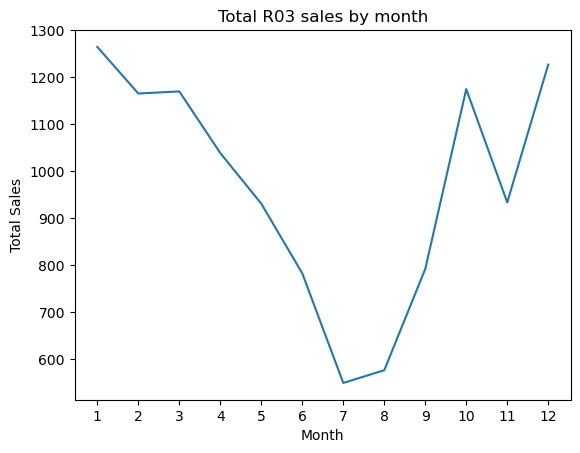

In [53]:
# Q6: Are respiratory drugs (R03) sold more during specific months?
df['datum'] = pd.to_datetime(df['datum'])
df['Month'] = df['datum'].dt.month
monthly_sales = df.groupby('Month')['R03'].sum()
print(monthly_sales)

y = monthly_sales.values
x = monthly_sales.index

fig, ax = plt.subplots()

ax.plot(x, y)
plt.title('Total R03 sales by month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.show()

In [57]:
# Q7:On which day of the week is the second drug (M01AE) most often sold?
df_7 = df[['Weekday Name', 'M01AE']]
result = df_7.groupby(['Weekday Name'], as_index=False).sum().sort_values('M01AE', ascending=False)
resultDay = result.iloc[0,0]
resultValue = round(result.iloc[0,1],2)
print(result)
print('M01AE was most sold on the day '+ str(resultDay))
print('Amounting to ' + str(resultValue))


  Weekday Name    M01AE
3       Sunday  1384.94
2     Saturday  1311.55
1       Monday  1118.50
0       Friday  1117.78
6    Wednesday  1110.25
4     Thursday  1092.28
5      Tuesday  1069.31
M01AE was most sold on the day Sunday
Amounting to 1384.94


In [ ]:
# Q8: Which drug has sold most often on Mondays in 2017?
drug_columns = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

monday_2017 = df[
    (df['datum'].dt.year == 2017) &
    (df['Weekday Name'] == 'Monday')
    ]

totals = monday_2017[drug_columns].sum().sort_values(ascending=False)
print(totals.head(1))

N02BE    1160.56
dtype: float64
